In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
import sys

sys.path.append("../utils")

import data_io

# setup

In [3]:
cm = 1/2.54  # centimeters in inches
plt.style.use('paper.mplstyle')

In [4]:
order = ["A17", "A2", "nNOS-1", "Other"]

cmap = {"RBC" :  "#0C7C59",
        "A2":    "#134D7C",
        "A17":   "#32A9DE",
        "nNOS-1":    "#B1DEF2",
        "Separate dendrites and axons":    "#B1DEF2",
        "Other": "#1D74B9" }


# load data

In [5]:
config = data_io.get_data_config()
version = config.get("version_rb", None)
file_path_celltypes = data_io.get_file_path(config,
                                  version = "version_rb",
                                  file_prefix = "file_prefix_rbc_celltypes")

file_path_synapses = data_io.get_file_path(config,
                                  version = "version_rb",
                                  file_prefix = "file_prefix_rbc_synapses")

In [6]:
assert os.path.isfile(file_path_celltypes), file_path_celltypes
assert os.path.isfile(file_path_synapses), file_path_synapses

In [7]:
celltype_df = pd.read_parquet(file_path_celltypes)
synapses_df = pd.read_parquet(file_path_synapses)

In [10]:
synapses_df

,pt_pre,pt_post,synapse_type,source,target,source_type,source_class,target_type,target_class
0,"[42722.28125, 36208.04296875, 715.5]","[42701.76171875, 36195.828125, 715.5]",ribbon,720575940567417708,720575940544951525,None,AC,None,None
1,"[42522.703125, 36251.7890625, 825.5000610351562]","[42545.6640625, 36253.25390625, 825.5000610351...",ribbon,720575940567417708,720575940569769761,None,AC,RBC,BC
2,"[42511.91015625, 36248.5, 808.592529296875]","[42528.5234375, 36248.5, 805.4657592773438]",ribbon,720575940567417708,720575940569769761,None,AC,RBC,BC
3,"[43207.765625, 35503.5625, 774.5000610351562]","[43228.7734375, 35498.1875, 774.5000610351562]",ribbon,720575940567417708,720575940556472535,None,AC,RBC,BC
4,"[42456.55859375, 36071.84375, 757.5]","[42458.0234375, 36095.296875, 757.5]",ribbon,720575940567417708,720575940569769761,None,AC,RBC,BC
...,...,...,...,...,...,...,...,...,...
447,"[42534.34375, 36230.69140625, 780.5]","[42534.8828125, 36244.63671875, 780.5]",conventional,720575940569769761,720575940567654385,RBC,BC,A2,AC
448,"[42466.52734375, 36115.5, 744.1353759765625]","[42473.76953125, 36115.5, 736.7350463867188]",conventional,720575940569769761,720575940557840651,RBC,BC,A2,AC
449,"[42760.1015625, 36536.66796875, 697.4999389648...","[42772.703125, 36536.1328125, 700.5]",conventional,720575940569769761,720575940567989001,RBC,BC,None,None
450,"[42720.546875, 36484.36328125, 640.4852905273438]","[42729.66015625, 36472.03125, 640.4852905273438]",conventional,720575940569769761,720575940567654385,RBC,BC,A2,AC


## rename celltypes

In [8]:
celltype_df = celltype_df.replace("A17 large", 'A17')       # remove distinction for simplicity
celltype_df = celltype_df.replace("A17 small", 'A17')

celltype_df = celltype_df.replace("H42", 'Other')           # preliminary prediction, remove for manuscript
celltype_df = celltype_df.replace("H52", 'Other')

celltype_df = celltype_df.replace("A1", 'n-NOS1')           # overwrite preliminary name given by classifier



In [11]:
synapses_df[['source_type', 'target_type']] = synapses_df[['source_type', 'target_type']].replace("A17 large", 'A17')
synapses_df[['source_type', 'target_type']] = synapses_df[['source_type', 'target_type']].replace("A17 small", 'A17')

synapses_df[['source_type', 'target_type']] = synapses_df[['source_type', 'target_type']].replace("H42", 'Other')
synapses_df[['source_type', 'target_type']] = synapses_df[['source_type', 'target_type']].replace("H52", 'Other')

synapses_df[['source_type', 'target_type']] = synapses_df[['source_type', 'target_type']].replace("A1", 'nNOS-1')

In [12]:
len(synapses_df), len(celltype_df)

(452, 124)

# overview

In [13]:
celltype_df.value_counts("Cell Type")  # all connections that occur only once will be filtered out

Cell Type
A17                              45
RBC                               9
n-NOS1                            8
A2                                4
Other                             4
Separate dendrites and axons      1
VIP1 (VIPm)                       1
Wide-field ON non-spiny dense     1
Name: count, dtype: int64

## output connections 

In [15]:
### get all synapses from RBC ###
cell_type = "RBC"
synapses_out = synapses_df[synapses_df['source_type'] == cell_type]
# ct_ids = np.unique(synapses_out['source'].values)
# len(ct_ids), len(synapses_out)

In [16]:
### remoove those which appear only once from type to type  ### 
counts = synapses_out.groupby(["source_type", "target_type"]).transform("size")
synapses_out = synapses_out[counts > 1]

In [17]:
### count synapses ##
synapse_counts = synapses_out.value_counts(subset = ['target_type'])
print('total output synapses per postsynaptic cell type')
print('------------------')
synapse_counts

total output synapses per postsynaptic cell type
------------------


target_type
A2             122
A17             84
nNOS-1           3
Name: count, dtype: int64

In [18]:
## count postsynaptic cells ###
celltype_counts = synapses_out.value_counts(subset = ['target_type'])
print('total output synapses per postsynaptic cell type')
print('------------------')
celltype_counts

total output synapses per postsynaptic cell type
------------------


target_type
A2             122
A17             84
nNOS-1           3
Name: count, dtype: int64

## input connections

In [19]:
### get all synapses from RBC ###

cell_type = "RBC"
synapses_in = synapses_df[synapses_df['target_type'] == cell_type]
# # synapses_in = synapses_df[synapses_df['target'].isin(segments)]
# ct_ids = np.unique(synapses_out['source'].values)
# ct_ids

# len(ct_ids), len(synapses_in)

In [20]:
### remoove those which appear only once from type to type  ### 
counts = synapses_in.groupby(["source_type", "target_type"]).transform("size")
synapses_in = synapses_in[counts > 1]

In [21]:
### count synapses ##

celltype_counts = synapses_in.value_counts(subset = ['source_type'])
print('total input synapses per presynaptic cell type')
print('------------------')

celltype_counts

total input synapses per presynaptic cell type
------------------


source_type
A17            108
Other           12
nNOS-1           7
Name: count, dtype: int64

In [22]:
## count pre-synaptic cells ###
celltype_counts = synapses_in.value_counts(subset = ['source_type'])
print('total input synapses per presynaptic cell type')
print('------------------')
celltype_counts

total input synapses per presynaptic cell type
------------------


source_type
A17            108
Other           12
nNOS-1           7
Name: count, dtype: int64

# figures

In [23]:
fig_dir = f'../figures/connectivity/v{version}'
os.makedirs(fig_dir, exist_ok=True)

In [24]:
# celltype_counts = synapses_out.value_counts(subset = ['target_type'])
# print('total output synapses per postsynaptic cell type')
# celltype_counts

In [25]:
# get all outgoing synapses per RBC per postsynaptic cell
celltype_counts = synapses_out.value_counts(subset = ['target_type', 'source'])   # count synapses per cell to target type
celltype_counts = pd.DataFrame(celltype_counts)
celltype_counts = celltype_counts.reset_index()
celltype_counts = celltype_counts.sort_values('target_type')

celltype_counts_out = celltype_counts
celltype_counts_out

,target_type,source,count
13,A17,720575940556018391,1
2,A17,720575940569769761,36
3,A17,720575940569047073,29
12,A17,720575940555250903,1
5,A17,720575940556472535,9
7,A17,720575940569043745,5
9,A17,720575940569780257,3
0,A2,720575940569769761,50
11,A2,720575940556018391,2
10,A2,720575940555250903,2


## panel D : outputs barplot

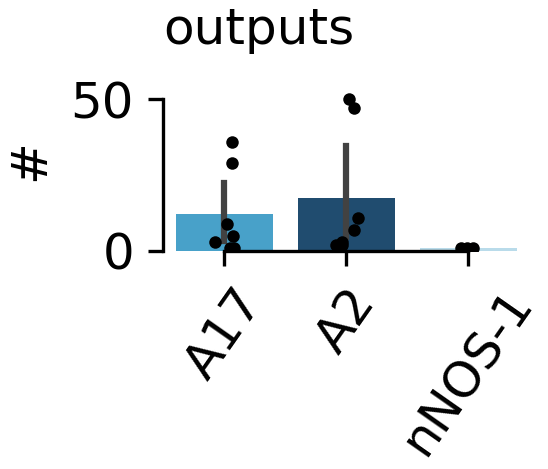

In [26]:
degree_type = 'count'
order = ["A17", "A2", "nNOS-1"]


fig  = plt.figure(figsize = (4*cm,2*cm))
ax = fig.add_subplot(111)

sns.barplot(data = celltype_counts_out, x = 'target_type', y = degree_type,
            hue = 'target_type',
            order = order,
            palette = cmap ,linewidth=0, edgecolor="k")

sns.stripplot(data = celltype_counts_out, x = 'target_type', y = degree_type,
              color = 'k',size = 3,
              order = order)


plt.xticks(rotation = 55)
plt.ylim(0,60)

ax.set_ylabel("#")
ax.set_xlabel("")

sns.despine(trim = True)


# ax.set_title(f"{cell_type} outputs", loc = 'left')
ax.set_title(f"outputs", loc = 'left')
fig.savefig(f'{fig_dir}/fig8_D_outputs_bar.svg')
fig.savefig(f'{fig_dir}/fig8_D_outputs_bar.png')

## panel D : inputs barplot

In [27]:
celltype_counts = synapses_in.value_counts(subset = ['source_type', 'target'])
celltype_counts = pd.DataFrame(celltype_counts)
celltype_counts = celltype_counts.reset_index()
celltype_counts = celltype_counts.sort_values('source_type')
# cell_types = list(celltype_counts['source_type'])
celltype_counts_in = celltype_counts

In [28]:
celltype_counts_in

,source_type,target,count
0,A17,720575940569043745,37
1,A17,720575940569769761,36
2,A17,720575940569047073,21
4,A17,720575940556472535,5
5,A17,720575940556018391,4
8,A17,720575940555250903,2
9,A17,720575940569780257,2
11,A17,720575940554483198,1
3,Other,720575940569047073,6
7,Other,720575940569043745,3


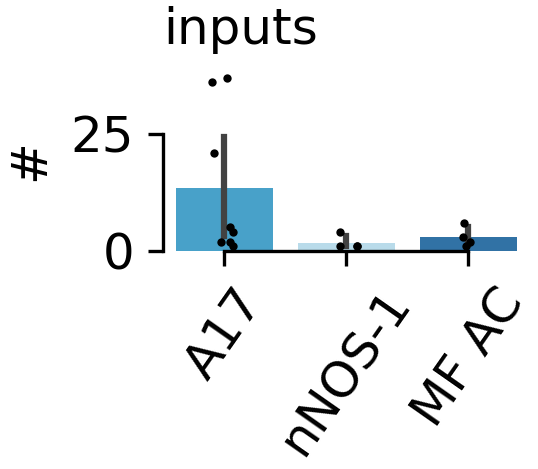

In [29]:
degree_type = 'count'

order = ["A17", "nNOS-1", "Other"]

fig  = plt.figure(figsize = (4*cm,2*cm))
ax = fig.add_subplot(111)

sns.barplot(data = celltype_counts_in, x = 'source_type', y = degree_type,
            hue = 'source_type',
            order = order,
            palette = cmap, linewidth=0, edgecolor=".5")

sns.stripplot(data = celltype_counts_in, x = 'source_type', y = degree_type,
              color = 'k', size = 2,
              order = order)

plt.xticks(rotation = 55)


sns.despine(trim = True)
ax.set_ylabel("#")
ax.set_xlabel("")
ax.set_xticklabels(["A17", "nNOS-1", "MF AC"])


ax.set_title(f"inputs", loc = 'left')
fig.savefig(f'{fig_dir}/fig8_D_inputs_bar.svg')
fig.savefig(f'{fig_dir}/fig8_D_inputs_bar.png')